<a href="https://colab.research.google.com/github/Naimur125/K-Means/blob/main/220106_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls /content

sample_data


In [ ]:
!git clone https://github.com/Naimur125/K-Means.git

Cloning into 'K-Means'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 41 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 13.72 KiB | 6.86 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [ ]:
%cd K-Means

/content/K-Means


In [ ]:
!ls

dataset  README.md  requirements.txt


In [ ]:
!ls dataset

custom_customers.csv  Mall_Customers.csv


In [ ]:
import pandas as pd

mall_df = pd.read_csv("dataset/Mall_Customers.csv")
mall_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
custom_df = pd.read_csv("dataset/custom_customers.csv")
custom_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,20,25,75
1,22,30,80
2,25,40,65
3,35,55,45
4,40,60,35


In [ ]:
mall_df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
X = mall_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
custom_df.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [ ]:
custom_df = custom_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

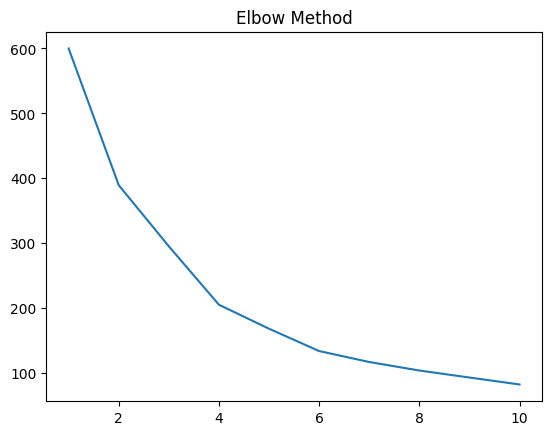

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import joblib

X = mall_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [ ]:
custom_X = custom_df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
custom_scaled = scaler.transform(custom_X)

custom_df['Cluster'] = kmeans.predict(custom_scaled)
custom_df

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,20,25,75,1
1,22,30,80,1
2,25,40,65,1
3,35,55,45,1
4,40,60,35,3
5,45,70,40,4
6,50,80,20,3
7,28,45,70,1
8,32,50,55,1
9,55,90,15,3


In [ ]:
import pandas as pd

mall_df = pd.read_csv("dataset/Mall_Customers.csv")
custom_df = pd.read_csv("dataset/custom_customers.csv")

mall_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X = mall_df[features]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

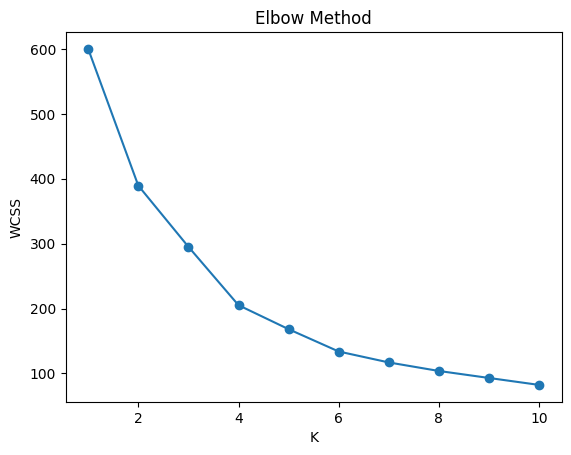

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

k = 5  # change ONLY if your graph clearly suggests different

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

mall_df["Cluster"] = kmeans.labels_
mall_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


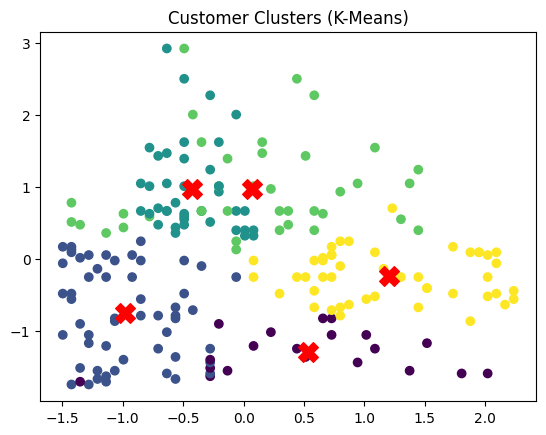

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=kmeans.labels_, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],
            s=200, c='red', marker='X')

plt.title("Customer Clusters (K-Means)")
plt.show()

In [ ]:
custom_X = custom_df[features]
custom_scaled = scaler.transform(custom_X)

custom_df["Cluster"] = kmeans.predict(custom_scaled)
custom_df

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,20,25,75,1
1,22,30,80,1
2,25,40,65,1
3,35,55,45,1
4,40,60,35,3
5,45,70,40,4
6,50,80,20,3
7,28,45,70,1
8,32,50,55,1
9,55,90,15,3


In [ ]:
import os
os.makedirs("model", exist_ok=True)

In [ ]:
import joblib

joblib.dump(kmeans, "model/kmeans_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']

In [ ]:
!ls model

kmeans_model.pkl  scaler.pkl


In [ ]:
!ls model

kmeans_model.pkl  scaler.pkl
